In [ ]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("../data/processed/cement_operations_clean.csv")


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

site = "SITE_001"

# Filter site and prepare date
site_df = df[df["site_id"] == site].copy()
site_df["date"] = pd.to_datetime(site_df["date"])
site_df = site_df.sort_values("date").set_index("date")

# Target variable
y = site_df["consumed_tonnes"]

# Exogenous variables
exog_columns = [
    "planned_pour_tonnes",
    "rain_mm",
    "avg_temp_c",
    "opening_inventory_tonnes",
    "deliveries_tonnes",
    "silo_capacity"
]

exog = site_df[exog_columns]

# Split data
split_index = int(len(site_df) * 0.8)

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

X_train = exog.iloc[:split_index]
X_test = exog.iloc[split_index:]

# Build SARIMAX model
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False
)

# Train model
results = model.fit()

print(results.summary())


c:\Users\HP\Documents\DS project\DS_project\nova-venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Documents\DS project\DS_project\nova-venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                   consumed_tonnes   No. Observations:                  876
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -3125.738
Date:                           Tue, 18 Aug 2026   AIC                           6273.476
Time:                                   23:25:45   BIC                           6325.878
Sample:                               01-01-2022   HQIC                          6293.531
                                    - 05-25-2024                                         
Covariance Type:                             opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
planned_pour_tonnes          0.5455      0.020     26.872      0.000       0.506       0.585
r

c:\Users\HP\Documents\DS project\DS_project\nova-venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:

# FIT MODEL
results = model.fit()
print(results.summary())


                                     SARIMAX Results                                     
Dep. Variable:                   consumed_tonnes   No. Observations:                  876
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -3125.738
Date:                           Tue, 18 Aug 2026   AIC                           6273.476
Time:                                   23:33:42   BIC                           6325.878
Sample:                               01-01-2022   HQIC                          6293.531
                                    - 05-25-2024                                         
Covariance Type:                             opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
planned_pour_tonnes          0.5455      0.020     26.872      0.000       0.506       0.585
r

c:\Users\HP\Documents\DS project\DS_project\nova-venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
# GENERATE FORECAST

forecast = results.get_forecast(
    steps=len(y_test),
    exog=X_test
)

predictions = forecast.predicted_mean


# CREATE ACTUAL VS PREDICTED DATAFRAME

comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": predictions
})

print(comparison.head(10))



            actual  predicted
2024-05-26   54.68  35.835353
2024-05-27   28.18  30.903357
2024-05-28    0.00  -1.321486
2024-05-29   40.29  30.621494
2024-05-30   32.99  30.661903
2024-05-31   11.57  18.764642
2024-06-01   28.28  29.772652
2024-06-02   30.32  32.313454
2024-06-03   45.29  39.922416
2024-06-04   23.55  16.909078


In [ ]:
#CREATE ACTUAL VS PREDICTED DATAFRAME


comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": predictions
})

print(comparison.head(10))


            actual  predicted
2024-05-26   54.68  35.835353
2024-05-27   28.18  30.903357
2024-05-28    0.00  -1.321486
2024-05-29   40.29  30.621494
2024-05-30   32.99  30.661903
2024-05-31   11.57  18.764642
2024-06-01   28.28  29.772652
2024-06-02   30.32  32.313454
2024-06-03   45.29  39.922416
2024-06-04   23.55  16.909078


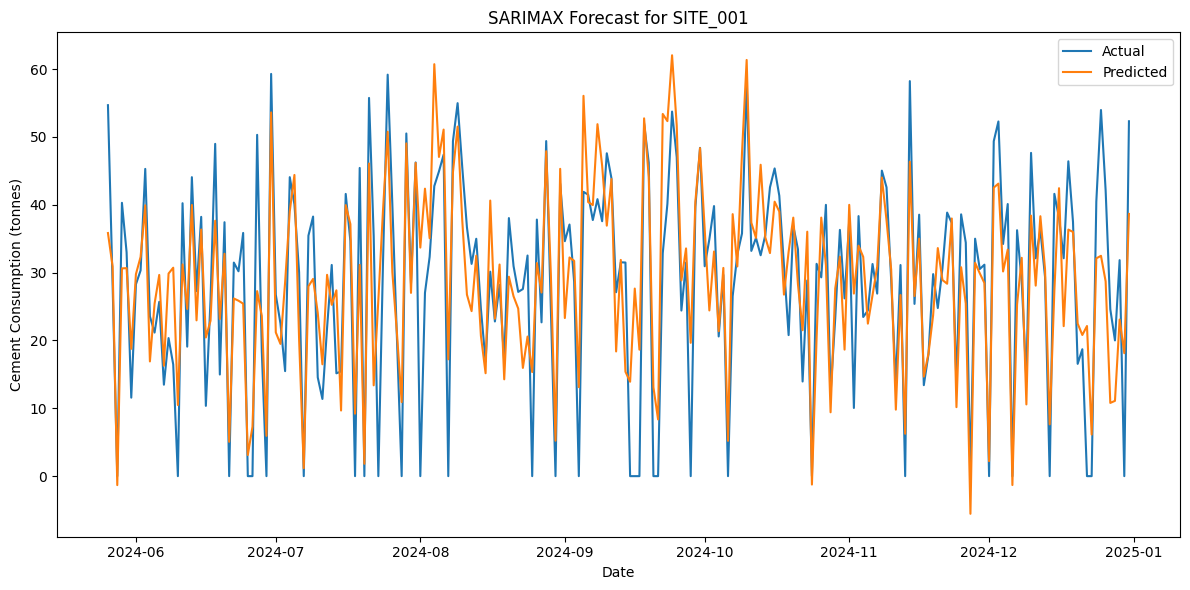

In [ ]:
 #PLOT ACTUAL VS PREDICTED

plt.figure(figsize=(12, 6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    predictions.index,
    predictions,
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Cement Consumption (tonnes)")
plt.title(f"SARIMAX Forecast for {site}")

plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# CALCULATE RESIDUALS

residuals = y_test - predictions

print("\nResidual statistics:")
print(residuals.describe())



Residual statistics:
count    220.000000
mean      -0.200045
std        9.023555
min      -33.689124
25%       -5.231141
50%        0.478468
75%        5.589317
max       23.036978
dtype: float64


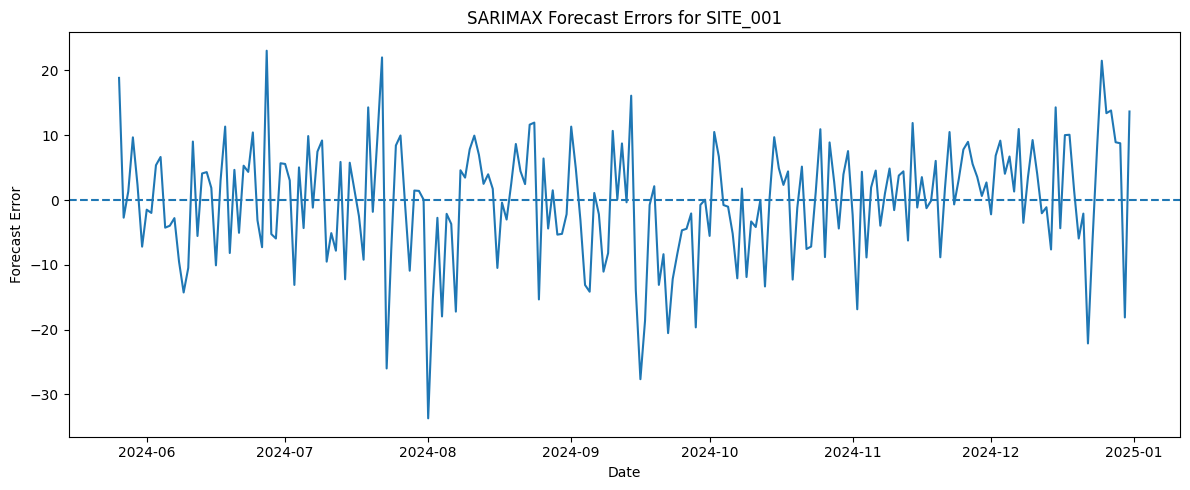

In [20]:
 # PLOT FORECAST ERRORS


plt.figure(figsize=(12, 5))

plt.plot(
    residuals.index,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.title(f"SARIMAX Forecast Errors for {site}")

plt.tight_layout()
plt.show()
